# Nigerian Sales Data Analysis

## Project Overview

This project explores Nigerian sales data using Python to understand customer demographics, purchasing patterns, regional performance, occupation, and product categories.

The analysis covers data cleaning, descriptive statistics, exploratory data analysis (EDA), aggregation, and visualization using Pandas, Seaborn, and Matplotlib.

### Questions explored

- How are sales distributed by gender?
- Which age groups contribute the most sales?
- Which states record the highest order volumes and sales?
- How do sales vary by marital status and gender?
- Which occupations contribute the most sales?
- Which product categories and products perform strongly?

> **Note:** The analysis describes patterns in this dataset. It does not establish causation, profitability, income level, or customer motivation where those variables are not present in the data.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


## 2. Load the Dataset

Place `NigerianSalesData.csv` in the same folder as this notebook before running it.

Using a relative path makes the notebook portable and allows other users to run it after cloning the repository.


In [2]:
df = pd.read_csv("NigerianSalesData.csv", encoding="unicode_escape")
df.head()


,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Chinedu Okafor,P00125942,F,26-35,28,0,Lagos,South West,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Emeka Nnamani,P00110942,F,26-35,35,1,Rivers,South South,Government,Auto,3,23934.0,NaN,NaN
2,1001990,Ifeanyi Balogun,P00118542,F,26-35,35,1,Kano,North Central,Automotive,Auto,3,23924.0,NaN,NaN
3,1001425,Obinna Ibrahim,P00237842,M,0-17,16,0,Oyo,South South,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Kelechi Lawal,P00057942,M,26-35,28,1,Edo,South West,Manufacturing,Auto,2,23877.0,NaN,NaN


## 3. Initial Data Inspection

In [3]:
df.shape


(11251, 15)

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  str    
 2   Product_ID        11251 non-null  str    
 3   Gender            11251 non-null  str    
 4   Age Group         11251 non-null  str    
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  str    
 8   Zone              11251 non-null  str    
 9   Occupation        11251 non-null  str    
 10  Product_Category  11251 non-null  str    
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), str(8)
memory usage: 1.3 MB


In [5]:
df.isnull().sum()


User_ID                 0
Cust_name               0
Product_ID              0
Gender                  0
Age Group               0
Age                     0
Marital_Status          0
State                   0
Zone                    0
Occupation              0
Product_Category        0
Orders                  0
Amount                 12
Status              11251
unnamed1            11251
dtype: int64

### Initial observations

The original dataset contains **11,251 rows and 15 columns**.

The `Status` and `unnamed1` columns contain no values and therefore do not contribute to the analysis. The `Amount` column contains 12 missing values.


## 4. Data Cleaning

### Remove columns with no usable values

`Status` and `unnamed1` are completely empty, so they are removed from the working dataset.


In [6]:
df = df.drop(columns=["Status", "unnamed1"])
df.head()


,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Chinedu Okafor,P00125942,F,26-35,28,0,Lagos,South West,Healthcare,Auto,1,23952.0
1,1000732,Emeka Nnamani,P00110942,F,26-35,35,1,Rivers,South South,Government,Auto,3,23934.0
2,1001990,Ifeanyi Balogun,P00118542,F,26-35,35,1,Kano,North Central,Automotive,Auto,3,23924.0
3,1001425,Obinna Ibrahim,P00237842,M,0-17,16,0,Oyo,South South,Construction,Auto,2,23912.0
4,1000588,Kelechi Lawal,P00057942,M,26-35,28,1,Edo,South West,Manufacturing,Auto,2,23877.0


### Handle missing values

There are 12 missing values in `Amount`. Because `Amount` is required for the sales-value analysis, rows with missing amounts are removed.


In [7]:
df = df.dropna(subset=["Amount"]).copy()

df.isnull().sum()


User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64

### Convert `Amount` to integer

After removing missing values, `Amount` can be converted from float to integer for consistency with the dataset's monetary values.


In [8]:
df["Amount"] = df["Amount"].astype(int)

df["Amount"].dtype


dtype('int64')

### Cleaned dataset

After cleaning, the working dataset contains **11,239 rows and 13 columns**.


In [9]:
df.shape


(11239, 13)

## 5. Descriptive Statistics

In [10]:
df.describe()


,User_ID,Age,Marital_Status,Orders,Amount
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610553
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355168
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


In [11]:
df[["Age", "Amount", "Orders"]].describe()


,Age,Amount,Orders
count,11239.000000,11239.000000,11239.000000
mean,35.410357,9453.610553,2.489634
std,12.753866,5222.355168,1.114967
min,12.000000,188.000000,1.000000
25%,27.000000,5443.000000,2.000000
50%,33.000000,8109.000000,2.000000
75%,43.000000,12675.000000,3.000000
max,92.000000,23952.000000,4.000000


The descriptive statistics show:

- Mean age: approximately **35.4 years**
- Median age: **33 years**
- Mean sales amount per row: approximately **9,453.61**
- Median sales amount per row: **8,109**
- Mean orders per row: approximately **2.49**

These statistics describe the observations in this dataset and should not be interpreted as population estimates for Nigeria as a whole.


# 6. Exploratory Data Analysis

## 6.1 Gender Analysis

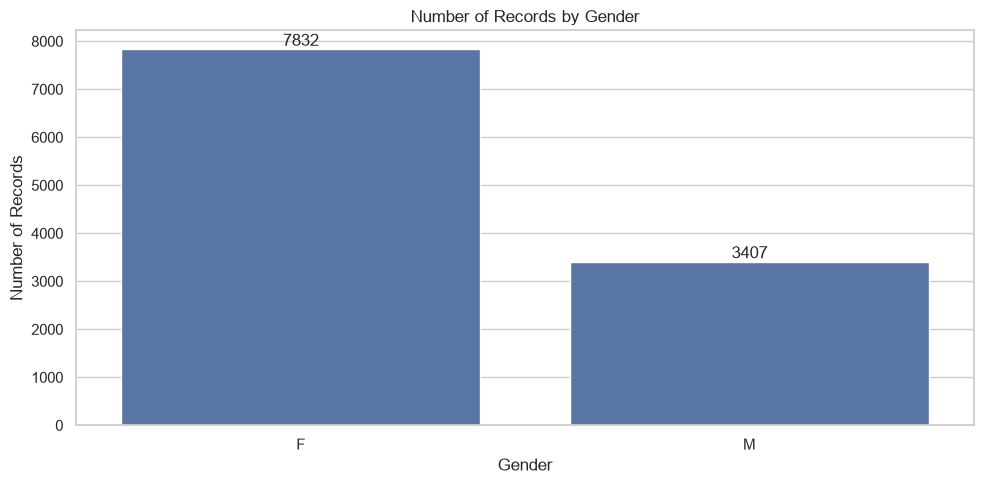

In [12]:
gender = sns.countplot(x="Gender", data=df)
gender.set_title("Number of Records by Gender")
gender.set_xlabel("Gender")
gender.set_ylabel("Number of Records")

for bars in gender.containers:
    gender.bar_label(bars)

plt.tight_layout()
plt.show()


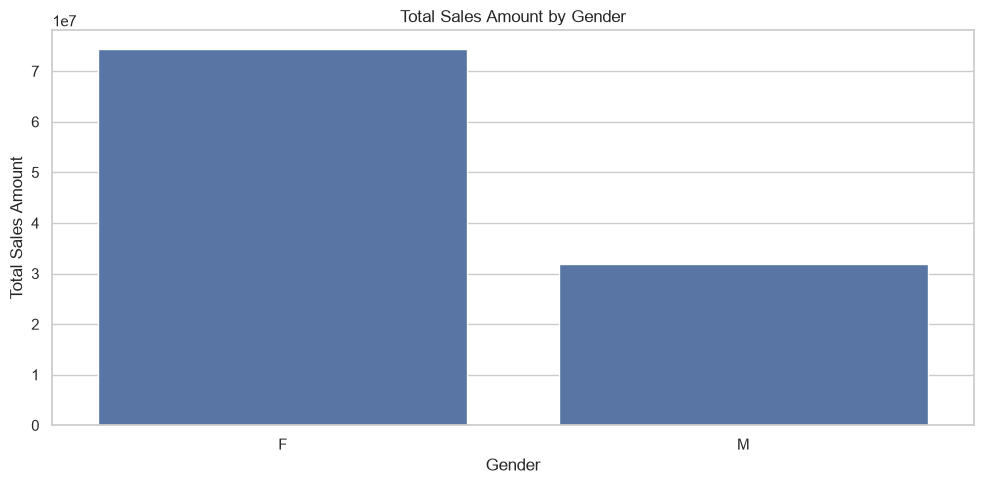

,Gender,Amount
0,F,74335853
1,M,31913276


In [13]:
gender_sales = (
    df.groupby("Gender", as_index=False)["Amount"]
      .sum()
      .sort_values("Amount", ascending=False)
)

sns.barplot(x="Gender", y="Amount", data=gender_sales)
plt.title("Total Sales Amount by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales Amount")
plt.tight_layout()
plt.show()

gender_sales


### Finding

Female customers account for the larger share of records and total sales amount in this dataset.


## 6.2 Age Group Analysis

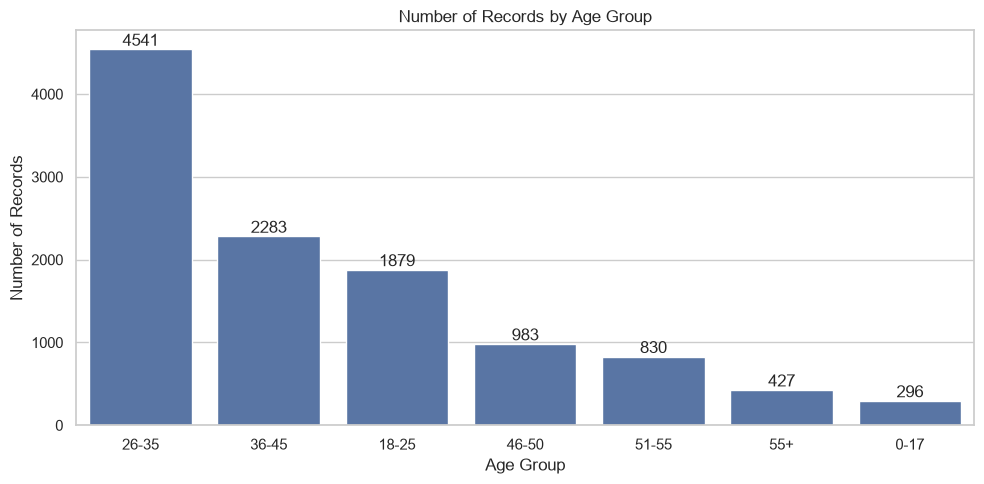

In [14]:
age_counts = sns.countplot(x="Age Group", data=df, order=df["Age Group"].value_counts().index)
age_counts.set_title("Number of Records by Age Group")
age_counts.set_xlabel("Age Group")
age_counts.set_ylabel("Number of Records")

for bars in age_counts.containers:
    age_counts.bar_label(bars)

plt.tight_layout()
plt.show()


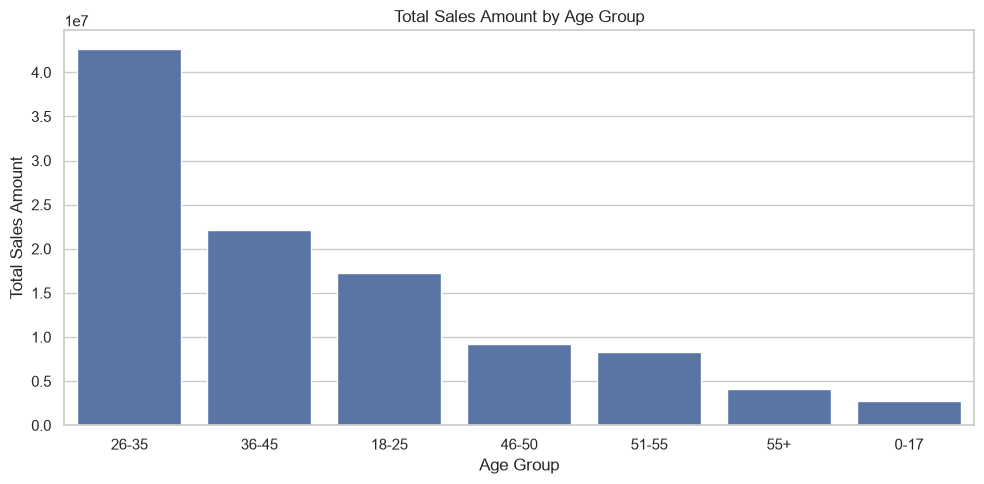

,Age Group,Amount
2,26-35,42613442
3,36-45,22144994
1,18-25,17240732
4,46-50,9207844
5,51-55,8261477
6,55+,4080987
0,0-17,2699653


In [15]:
age_sales = (
    df.groupby("Age Group", as_index=False)["Amount"]
      .sum()
      .sort_values("Amount", ascending=False)
)

sns.barplot(x="Age Group", y="Amount", data=age_sales)
plt.title("Total Sales Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Sales Amount")
plt.tight_layout()
plt.show()

age_sales


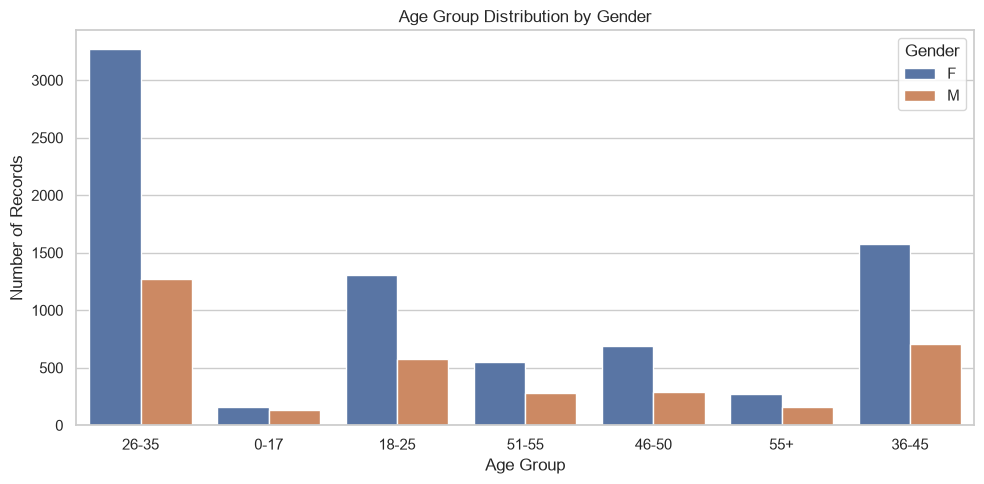

In [16]:
age_gender = sns.countplot(x="Age Group", hue="Gender", data=df)
age_gender.set_title("Age Group Distribution by Gender")
age_gender.set_xlabel("Age Group")
age_gender.set_ylabel("Number of Records")
plt.tight_layout()
plt.show()


### Finding

The **26–35** age group contributes the highest total sales amount in the dataset, followed by **36–45** and **18–25**.

This describes sales performance by age group in the dataset; it does not by itself establish why these groups spend more.


## 6.3 State Analysis

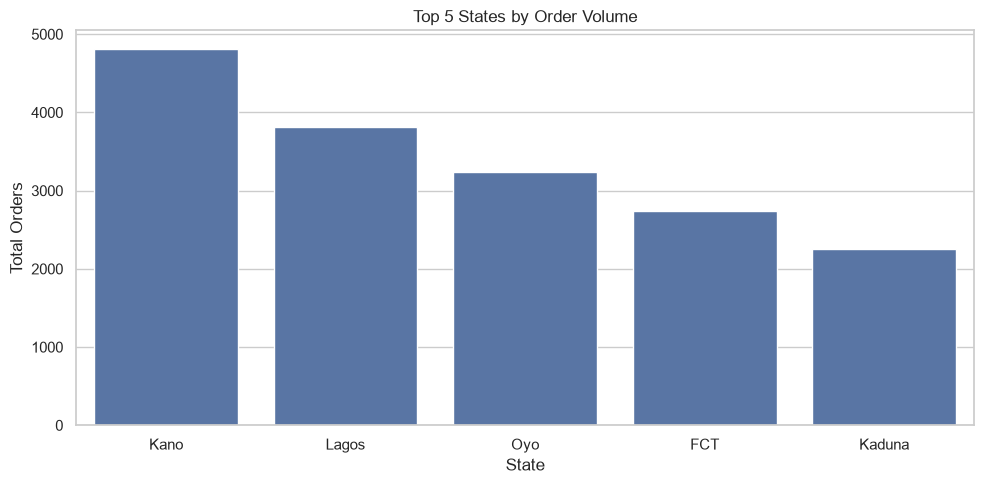

,State,Orders
8,Kano,4807
10,Lagos,3810
12,Oyo,3240
6,FCT,2740
7,Kaduna,2252


In [17]:
state_orders = (
    df.groupby("State", as_index=False)["Orders"]
      .sum()
      .sort_values("Orders", ascending=False)
      .head(5)
)

sns.barplot(data=state_orders, x="State", y="Orders")
plt.title("Top 5 States by Order Volume")
plt.xlabel("State")
plt.ylabel("Total Orders")
plt.tight_layout()
plt.show()

state_orders


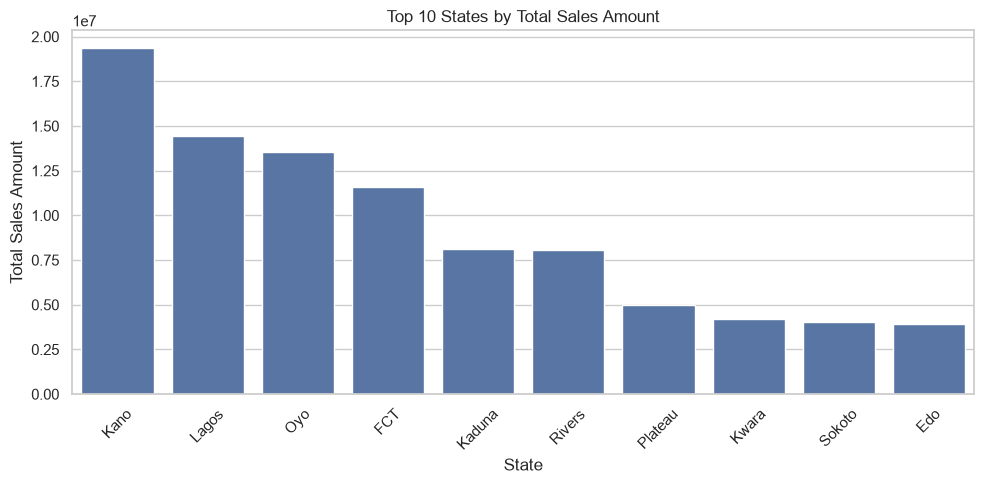

,State,Amount
8,Kano,19374968
10,Lagos,14427543
12,Oyo,13523540
6,FCT,11603818
7,Kaduna,8101142
14,Rivers,8037146
13,Plateau,4963368
9,Kwara,4220175
15,Sokoto,4022757
4,Edo,3946082


In [18]:
state_sales = (
    df.groupby("State", as_index=False)["Amount"]
      .sum()
      .sort_values("Amount", ascending=False)
      .head(10)
)

sns.barplot(data=state_sales, x="State", y="Amount")
plt.title("Top 10 States by Total Sales Amount")
plt.xlabel("State")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

state_sales


### Finding

Kano has the highest order volume and the highest total sales amount among the states in this dataset. Lagos and Oyo also rank highly by both measures.


## 6.4 Marital Status Analysis

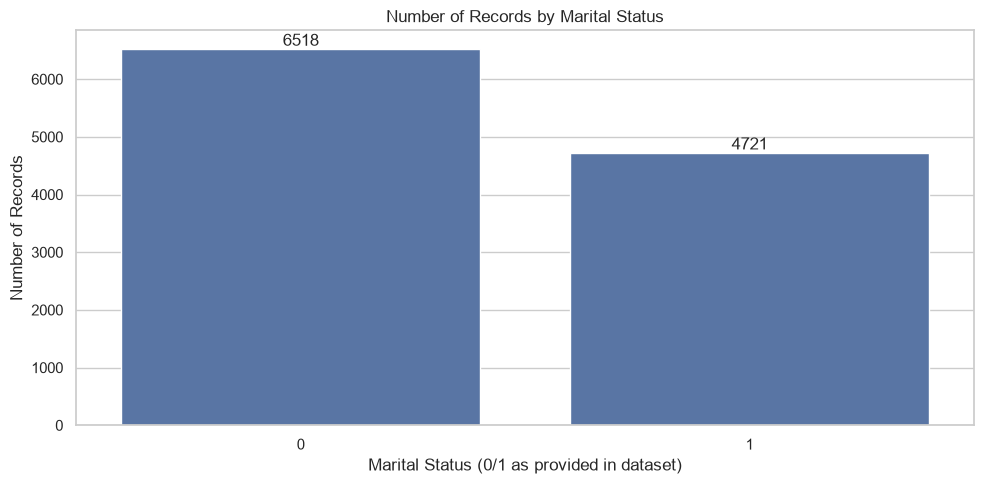

In [19]:
marital = sns.countplot(x="Marital_Status", data=df)
marital.set_title("Number of Records by Marital Status")
marital.set_xlabel("Marital Status (0/1 as provided in dataset)")
marital.set_ylabel("Number of Records")

for bars in marital.containers:
    marital.bar_label(bars)

plt.tight_layout()
plt.show()


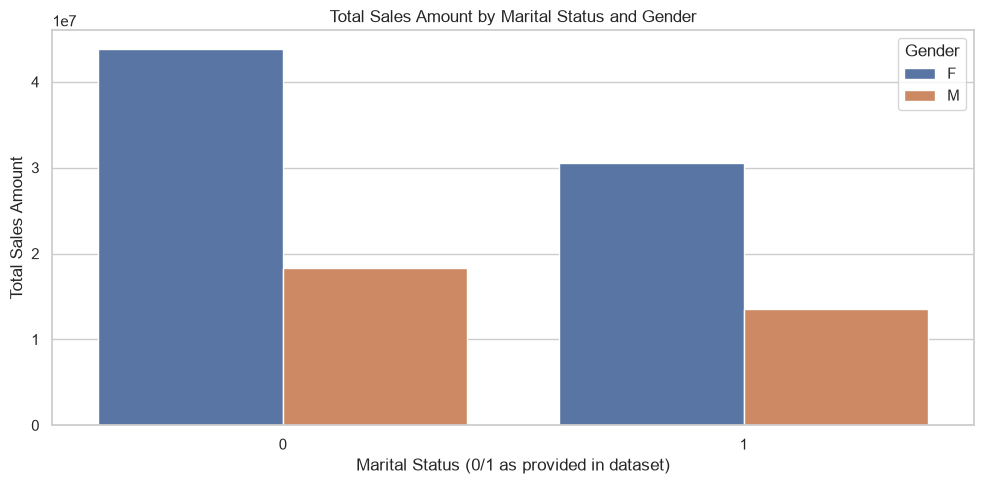

,Marital_Status,Gender,Amount
0,0,F,43786646
2,1,F,30549207
1,0,M,18338738
3,1,M,13574538


In [20]:
marital_sales = (
    df.groupby(["Marital_Status", "Gender"], as_index=False)["Amount"]
      .sum()
      .sort_values("Amount", ascending=False)
)

sns.barplot(
    x="Marital_Status",
    y="Amount",
    hue="Gender",
    data=marital_sales
)
plt.title("Total Sales Amount by Marital Status and Gender")
plt.xlabel("Marital Status (0/1 as provided in dataset)")
plt.ylabel("Total Sales Amount")
plt.tight_layout()
plt.show()

marital_sales


### Finding

When marital status and gender are considered together, female customers have higher total sales amounts than male customers in both marital-status categories represented in the dataset.

The dataset uses `0` and `1` for `Marital_Status`; the notebook does not assume a label for those values without a data dictionary.


## 6.5 Occupation Analysis

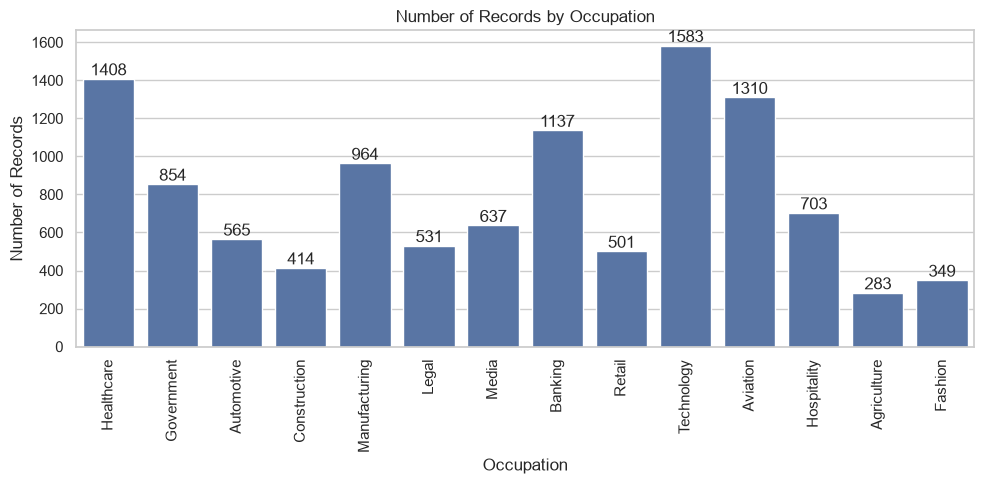

In [21]:
occupation_counts = sns.countplot(x="Occupation", data=df)
occupation_counts.set_title("Number of Records by Occupation")
occupation_counts.set_xlabel("Occupation")
occupation_counts.set_ylabel("Number of Records")
plt.xticks(rotation=90)

for bars in occupation_counts.containers:
    occupation_counts.bar_label(bars)

plt.tight_layout()
plt.show()


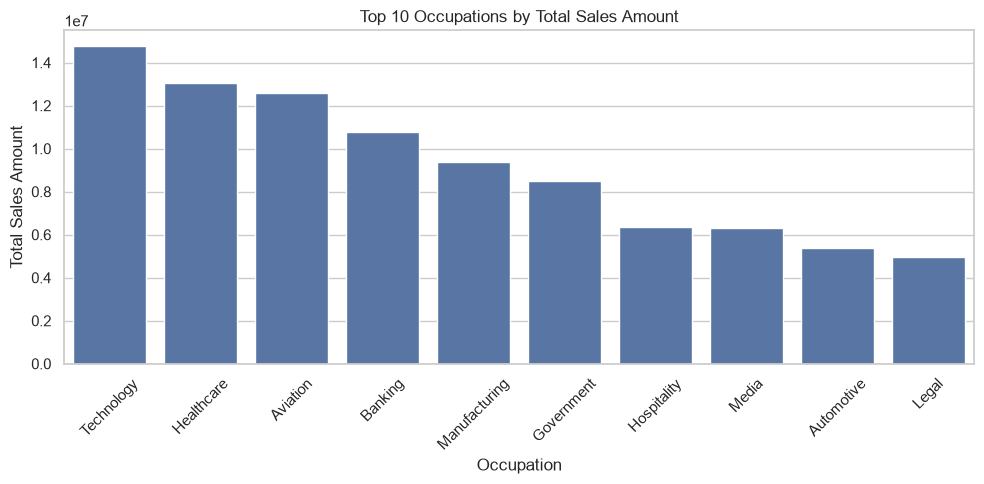

,Occupation,Amount
13,Technology,14755079
7,Healthcare,13034586
2,Aviation,12602298
3,Banking,10770610
10,Manufacturing,9368106
6,Government,8517212
8,Hospitality,6376405
11,Media,6295832
1,Automotive,5368596
9,Legal,4981665


In [22]:
occupation_sales = (
    df.groupby("Occupation", as_index=False)["Amount"]
      .sum()
      .sort_values("Amount", ascending=False)
      .head(10)
)

sns.barplot(data=occupation_sales, x="Occupation", y="Amount")
plt.title("Top 10 Occupations by Total Sales Amount")
plt.xlabel("Occupation")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

occupation_sales


### Finding

Technology, Healthcare, Aviation, and Banking are among the highest-contributing occupation groups by total sales amount in this dataset.


## 6.6 Product Category Analysis

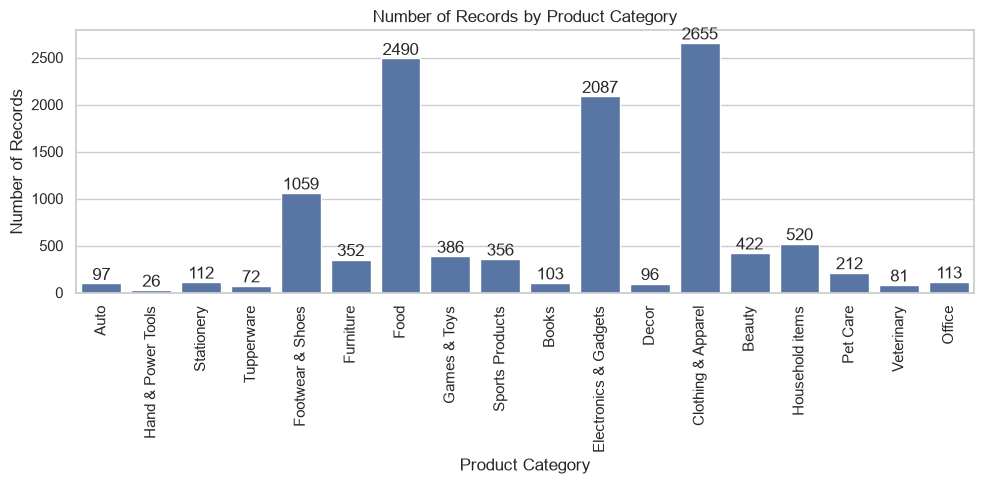

In [23]:
category_counts = sns.countplot(x="Product_Category", data=df)
category_counts.set_title("Number of Records by Product Category")
category_counts.set_xlabel("Product Category")
category_counts.set_ylabel("Number of Records")
plt.xticks(rotation=90)

for bars in category_counts.containers:
    category_counts.bar_label(bars)

plt.tight_layout()
plt.show()


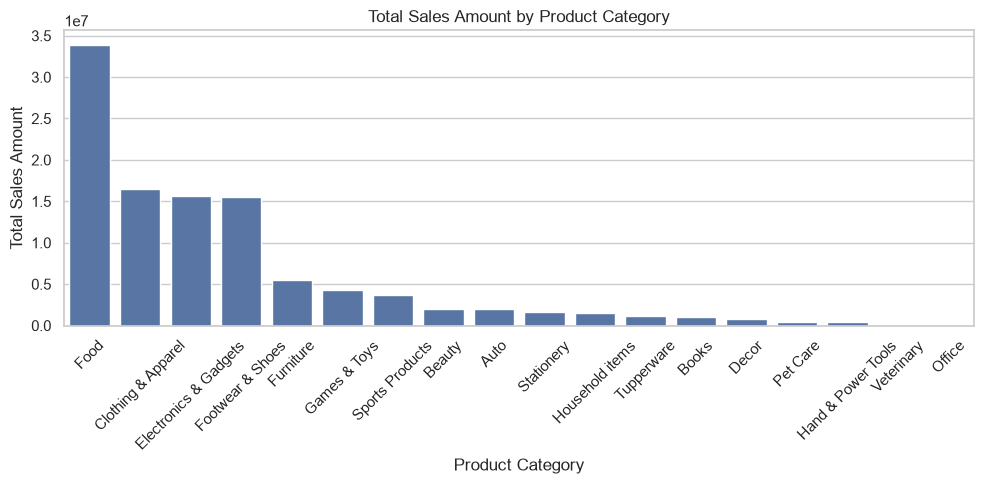

,Product_Category,Amount
6,Food,33933883
3,Clothing & Apparel,16495019
5,Electronics & Gadgets,15643846
7,Footwear & Shoes,15575209
8,Furniture,5440051
9,Games & Toys,4331694
14,Sports Products,3635933
1,Beauty,1959484
0,Auto,1958609
15,Stationery,1676051


In [24]:
category_sales = (
    df.groupby("Product_Category", as_index=False)["Amount"]
      .sum()
      .sort_values("Amount", ascending=False)
)

sns.barplot(data=category_sales, x="Product_Category", y="Amount")
plt.title("Total Sales Amount by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

category_sales


### Finding

Food is the highest-performing product category by total sales amount in this dataset, followed by Clothing & Apparel, Electronics & Gadgets, and Footwear & Shoes.


## 6.7 Product-Level Order Analysis

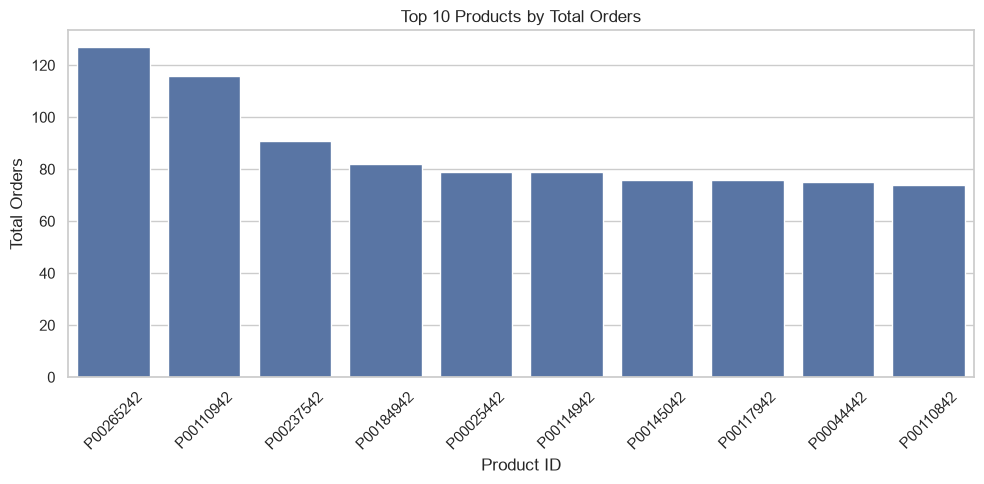

,Product_ID,Orders
1679,P00265242,127
644,P00110942,116
1504,P00237542,91
1146,P00184942,82
171,P00025442,79
679,P00114942,79
888,P00145042,76
708,P00117942,76
298,P00044442,75
643,P00110842,74


In [25]:
top_products = (
    df.groupby("Product_ID", as_index=False)["Orders"]
      .sum()
      .sort_values("Orders", ascending=False)
      .head(10)
)

sns.barplot(data=top_products, x="Product_ID", y="Orders")
plt.title("Top 10 Products by Total Orders")
plt.xlabel("Product ID")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

top_products


### Finding

A relatively small number of products account for a high number of orders. Order frequency is useful for identifying popular products, but it does not measure profitability because profit and margin are not included in the dataset.


# 7. Key Findings

Based on the analysis:

1. Female customers generated the larger share of total sales.
2. The **26–35** age group generated the highest total sales amount.
3. **Kano** recorded the highest order volume and total sales amount among the states analyzed.
4. Technology, Healthcare, Aviation, and Banking were among the leading occupation groups by sales.
5. **Food** was the leading product category by total sales amount.
6. Clothing & Apparel, Electronics & Gadgets, and Footwear & Shoes were also major contributors.
7. A small group of products recorded relatively high order volumes.

## 8. Business Considerations

The findings can support:

- Customer segmentation
- Regional marketing analysis
- Inventory planning
- Product performance monitoring
- Targeted promotional campaigns

However, decisions about profitability or customer income should not be made from this dataset alone because variables such as cost, profit margin, income, marketing spend, and transaction dates are not available in the notebook.

## 9. Limitations

- The dataset does not include profit or cost, so sales amount should not be treated as profit.
- There is no transaction date in the analyzed columns, so time-based sales trends cannot be assessed.
- The dataset's `Marital_Status` values are coded as `0` and `1`, and their exact labels are not established in the notebook.
- The analysis describes this dataset and should not automatically be generalized to all Nigerian consumers.
- Customer names and IDs are present in the source data. If the dataset is not explicitly public or synthetic, anonymize personal information before publishing it to GitHub.

## 10. Future Improvements

Potential extensions include:

- Time-series sales analysis if transaction dates are available
- Profit and profit-margin analysis
- Average order value
- Customer segmentation
- Product profitability
- Interactive Tableau or Power BI dashboards
- Statistical testing of relationships between customer characteristics and sales

## Conclusion

This project demonstrates a complete exploratory data-analysis workflow: loading data, inspecting data quality, cleaning missing values, transforming variables, aggregating data, and communicating findings through visualizations.

The analysis highlights meaningful differences across gender, age group, state, occupation, marital status, and product category within the dataset.
